# Plotting covariance matrices

This is a notebook in which we can plot the results of our covariance matrix generation, signal-to-noise ratio etc

## 1 Packages <a id='packages'></a>
[Back to content](#content)

In [197]:
# Load packages
%matplotlib inline
import os
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import pickle
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata

# Use TeX
from matplotlib import rc
rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

## 2 Reading in data 

## 2.1 Reading in distributions

Here, we read in our  redshift distributions, which gives us several important parameters we'll need in the plotting

In [198]:
def load_file(filename):
    """Loads a pickled dictionary"""
    with open(filename, "rb") as f:
        data = pickle.load(f)  # Load the dictionary from the pickle file

    return(data)

#the file containing the redshift distributions
redshift_distributions = load_file(f"data/redshift_distributions")

Nbinz_E = redshift_distributions["E"].Nbinz
Nbinz_P = redshift_distributions["P"].Nbinz

Nbinz = {'LP': Nbinz_P,
         'LE': Nbinz_E,
         'LL': 0
        }

### 2.2 Reading in $L$ and $\langle \eta_\mathrm{LOS} \rangle$ grid and covariances

Here, we read in the grid of mean LOS measurement errors $\langle \eta_\mathrm{LOS} \rangle$ and the number of lenses $L$ for which each value of noise and sparsity variance has been calculated, as well as the data dictionaries, containing the signal, variance, angular binschemes, and cosmic, noise and sparsity contributions

In [199]:
covariance_dict = load_file(f"data/covariance_dict_min2arcmin") 
#add "_min2arcmin" for the data with theta_optimised_min = 2 arcmin, omit for unrestricted theta_optimised_min

In [200]:
# Read parameters from params.txt
sigma_L_array = covariance_dict['sigL']
Nlens_array = covariance_dict['Nlens']
LLLL_plus_dicts = covariance_dict['LLp']
LLLL_minus_dicts = covariance_dict['LLm']
LELE_plus_dicts = covariance_dict['LEp']
LELE_minus_dicts = covariance_dict['LEm']
LPLP_dicts = covariance_dict['LP']

## 3. Plotting

### 3.1 Keys

In [201]:
titles = {'LLm': r'$(\mathrm{LL})^-$',
                 'LLp': r'$(\mathrm{LL})^+$',
                 'LEm': r'$(\mathrm{LE})^-$',
                 'LEp': r'$(\mathrm{LE})^+$',
                 'LP': r'$(\mathrm{LP})$'
}

dictionary_dict = {'LLm': LLLL_minus_dicts,
                 'LLp': LLLL_plus_dicts,
                 'LEm': LELE_minus_dicts,
                 'LEp': LELE_plus_dicts,
                 'LP': LPLP_dicts
}

### 3.2 Single plot function

In [202]:
def format_sci(value):
    """Format a number as LaTeX scientific notation."""
    if value == 0:
        return "0"

    exp = int(np.floor(np.log10(abs(value))))
    x = value / 10**exp

    # Avoid floating precision issues (e.g. 0.999999999)
    if np.isclose(x, 1):
        return rf"$10^{{{exp}}}$"
    else:
        return rf"${x:.2g} \times 10^{{{exp}}}$"

def plot_SNR_grid_single(correlation, relative=True, colours=True, log_scale=True, set_extent = False,
                  figsize=(9, 8), smooth=True, interp_resolution=200, snr_smooth_sigma=1.0,
                 plot_noise = True, plot_cosmic = True, plot_sparsity=True, ax=None, ylabel=True, xlabel=True, add_colourbar=True):
    """
    A grid of SNR vs sigma_L and Nlens

    Args:
        correlation: str, which correlation function we're interested in
        relative: bool, if True, plots the relative contribution of variance source per pixel
        colours: bool, whether to separate out noise/cosmic/sparsity into colours
        log_scale: bool, if True, plot log10(SNR) (does nothing if relative = True)
        figsize: tuple, figure size
        smooth: bool, whether to interpolate to smooth colours between pixels
        interp_resolution: int, number of points in interpolation grid
        snr_smooth_sigma: float, Gaussian sigma for smoothing SNR contours
    """

    ############################################################################
    ################################ Data setup ################################

    data_dict = dictionary_dict[correlation]
    
    unique_sigma_L = np.unique(sigma_L_array)        # the unique sigma_L values making up the grid
    unique_Nlens = np.unique(Nlens_array)            # the unique Nlens values making up the grid

    # mapping sigma_L and Nlens to indices that can be used to match them to the corresponding noise and sparsity variance 
    param_dict = {(sl, nl): i
                  for i, (sl, nl) in enumerate(zip(sigma_L_array, Nlens_array))}
    
    n_sigma = len(unique_sigma_L) # the number of sigma_L values
    n_nlens = len(unique_Nlens)   # the number of Nlens values

    # Build grids
    SNR_grid = np.zeros((n_nlens, n_sigma)) # empty grid for snr
    ccov_grid = np.zeros_like(SNR_grid) # empty grid for sparsity
    scov_grid = np.zeros_like(SNR_grid) # empty grid for sparsity
    ncov_grid = np.zeros_like(SNR_grid) # empty grid for noise
    theta_grid = np.zeros_like(SNR_grid) # empty grid for theta

    # loop through the Nlens values
    for i, nl in enumerate(unique_Nlens):

        # loop through the sigma_L values
        for j, sl in enumerate(unique_sigma_L):

            idx = param_dict[(sl, nl)] # the index of this sl, nl combination

            # place sparsity and noise variance in their correct places on the grid
            SNR_grid[i, j] = data_dict[idx]['optimised_SNR'] 
            ccov_grid[i, j] = data_dict[idx]['optimised_cosmic'] 
            ncov_grid[i, j] = data_dict[idx]['optimised_noise'] 
            scov_grid[i, j] = data_dict[idx]['optimised_sparsity']
            theta_grid[i, j] = data_dict[idx]['optimised_theta']  

    #### Derived quantities ####
    
    # Apply variance source switches
    ccov_used = ccov_grid if plot_cosmic else np.zeros_like(ccov_grid)
    ncov_used = ncov_grid if plot_noise else np.zeros_like(ncov_grid)
    scov_used = scov_grid if plot_sparsity else np.zeros_like(scov_grid)
    
    # Total variance only includes selected components
    total_sqr = ccov_used + ncov_used + scov_used
    
    # matrices of the standard deviation (square root of the variance)
    cosmic_mat = np.sqrt(np.abs(ccov_used))
    noise_mat = np.sqrt(np.abs(ncov_used))
    sparsity_mat = np.sqrt(np.abs(scov_used))
    totals = np.sqrt(np.abs(total_sqr))
    
    # Prevent divide-by-zero in later normalisations
    totals[totals == 0] = 1e-30


    if relative or colours: # if we are only interested in the relative contribution, pixel by pixel
        # normalize individual components by the total in that pixel
        noise_mat /= totals
        cosmic_mat /= totals
        sparsity_mat /= totals

    # if we want the log of the SNR
    if log_scale: 
        SNR_grid = np.log10(np.maximum(SNR_grid, 1e-30))

    #### Logarithmic axes ####

    # the log values of the unique grid values
    log_sigma_orig = np.log10(unique_sigma_L)
    log_nlens_orig = np.log10(unique_Nlens)

    #### clipping ####

    log_sigma_L_min = xlims[correlation][0]
    log_sigma_L_max = xlims[correlation][1]  
    log_Nlens_min = ylims[correlation][0]
    log_Nlens_max = ylims[correlation][1]

    # masks
    mask_sigma = (log_sigma_orig >= log_sigma_L_min) & (log_sigma_orig <= log_sigma_L_max)
    mask_nlens = (log_nlens_orig >= log_Nlens_min) & (log_nlens_orig <= log_Nlens_max)

    # rescale = 
    
    # crop data
    noise_mat     = noise_mat[mask_nlens][:, mask_sigma]
    cosmic_mat    = cosmic_mat[mask_nlens][:, mask_sigma]
    sparsity_mat  = sparsity_mat[mask_nlens][:, mask_sigma]
    SNR_grid      = SNR_grid[mask_nlens][:, mask_sigma]
    
    # crop axes
    log_sigma_orig = log_sigma_orig[mask_sigma]
    log_nlens_orig = log_nlens_orig[mask_nlens]

    #### Interpolation ####
    
    if smooth:

        # empty lists to hold values for interpolation
        points = []
        v_noise = []
        v_cosmic = []
        v_sparse = []
        v_snr = []

        # loop through the Nlens values (log space)
        for i, log_nl in enumerate(log_nlens_orig):

            # loop through the sl values (log space)
            for j, log_sl in enumerate(log_sigma_orig):

                # populate lists for interpolation
                points.append([log_sl, log_nl])
                v_noise.append(noise_mat[i, j])
                v_cosmic.append(cosmic_mat[i, j])
                v_sparse.append(sparsity_mat[i, j])
                v_snr.append(SNR_grid[i, j])

        # turn lists into arrays
        points = np.array(points)
        v_noise = np.array(v_noise)
        v_cosmic = np.array(v_cosmic)
        v_sparse = np.array(v_sparse)
        v_snr = np.array(v_snr)

        # fine grid for interpolation
        log_sigma_fine = np.linspace(log_sigma_orig.min(), log_sigma_orig.max(), interp_resolution)
        log_nlens_fine = np.linspace(log_nlens_orig.min(), log_nlens_orig.max(), interp_resolution)
        log_sigma_grid, log_nlens_grid = np.meshgrid(log_sigma_fine, log_nlens_fine)

        # Interpolate
        noise_mat = griddata(points, v_noise, (log_sigma_grid, log_nlens_grid), method='cubic', fill_value=0)
        cosmic_mat = griddata(points, v_cosmic, (log_sigma_grid, log_nlens_grid), method='cubic', fill_value=0)
        sparsity_mat = griddata(points, v_sparse, (log_sigma_grid, log_nlens_grid), method='cubic', fill_value=0)

        #grid and interpolation for total snr
        SNR_grid = griddata(points, v_snr, (log_sigma_grid, log_nlens_grid), method='cubic', fill_value=np.nan)
        SNR_grid = np.nan_to_num(SNR_grid, nan=np.nanmin(SNR_grid))
            
        # Gaussian smoothing
        SNR_grid = gaussian_filter(SNR_grid, sigma=snr_smooth_sigma)

        # Renormalize relative contributions
        if relative:
            tot_interp = np.sqrt(noise_mat**2 + cosmic_mat**2 + sparsity_mat**2)
            noise_mat /= tot_interp
            cosmic_mat /= tot_interp
            sparsity_mat /= tot_interp

        # the upper and lower bounds of each axis in the interpolated grid
        original_extent = [log_sigma_fine.min(), log_sigma_fine.max(),
                  log_nlens_fine.min(), log_nlens_fine.max()]

        # the values we'll use for the plot if we've interpolated
        sigma_plot, nlens_plot = log_sigma_grid, log_nlens_grid

    else: #if we're not interpolating,
        
        # the upper and lower bounds of each axis in the course grid
        original_extent = [log_sigma_orig.min(), log_sigma_orig.max(),
                  log_nlens_orig.min(), log_nlens_orig.max()]

        # the values we'll use for the plot if we haven't interpolated
        sigma_plot, nlens_plot = np.meshgrid(log_sigma_orig, log_nlens_orig)

    extent = original_extent

    ##############################################################################
    ################################## Plotting ##################################

    # setting up the figure
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
        created_fig = True
    else:
        created_fig = False
    
    if relative or colours: # if the components will be separated in our final plot
        if relative: # if we're only plotting the relative contributions in each pixel
            
            # RGB relative fractions
            rgb = np.zeros(noise_mat.shape + (3,)) # an rgb matrix to hold our data
            rgb[..., 0] = cosmic_mat # red is cosmic 
            rgb[..., 1] = noise_mat # green is noise
            rgb[..., 2] = sparsity_mat #blue is sparsity
            rgb = np.clip(rgb, 0, 1) #each component should already lie between 0 and 1, but this makes sure

            #plot the RGB matrix
            ax.imshow(rgb, extent=extent, origin='lower', aspect='auto')
            
        else:
            # brightness based on SNR
            if log_scale:
                snr_intensity = (SNR_grid - np.nanmin(SNR_grid)) / (np.nanmax(SNR_grid) - np.nanmin(SNR_grid))
            else:
                snr_intensity = SNR_grid / np.nanmax(SNR_grid)

            #the components of our RGB matrix are the colours x the snr intensity
            rgb = np.zeros(noise_mat.shape + (3,))
            rgb[..., 0] = cosmic_mat * snr_intensity
            rgb[..., 1] = noise_mat  * snr_intensity
            rgb[..., 2] = sparsity_mat * snr_intensity
            rgb = np.clip(rgb, 0, 1)

            ax.imshow(rgb, extent=extent, origin='lower', aspect='auto')

    else:
        # Heatmap of SNR
        im = ax.imshow(SNR_grid, extent=extent, origin='lower', aspect='auto', cmap='inferno_r')
    
        if add_colourbar:
            cbar = plt.colorbar(im, ax=ax)
            cbar.set_label("log10(SNR)" if log_scale else "SNR")

    # contours
    # contour_levels_lin = np.logspace(-1.4, 1.8, 20)
    contour_levels_lin = np.array([1, 30, 100, 300, 900]) #with a dotted line
    contour_levels_lin1 = np.array([5]) #with a solid line
    contour_levels_log = np.log10(contour_levels_lin)
    contour_levels_log1 = np.log10(contour_levels_lin1)
    
    # Choose which to plot
    levels = contour_levels_log if log_scale else contour_levels_lin
    levels1 = contour_levels_log1 if log_scale else contour_levels_lin1

    #plot the dashed contours
    CS = ax.contour(
        sigma_plot,
        nlens_plot,
        SNR_grid,
        levels=levels,
        colors='white',
        linewidths=1.2,
        linestyles='dashed'
    )

    #plot the solid contours
    CS1 = ax.contour(
        sigma_plot,
        nlens_plot,
        SNR_grid,
        levels=levels1,
        colors='white',
        linewidths=1.2,
        linestyles='solid'
    )
    
    # Format labels
    if log_scale:
        fmt  = {lvl: fr"{s:.0f}$\sigma$"
                for s, lvl in zip(contour_levels_lin, contour_levels_log)}
        fmt1 = {lvl: fr"{s:.0f}$\sigma$"
                for s, lvl in zip(contour_levels_lin1, contour_levels_log1)}
    else:
        fmt  = {lvl: fr"{lvl:.0f}$\sigma$"
                for lvl in contour_levels_lin}
        fmt1 = {lvl: fr"{lvl:.0f}$\sigma$"
                for lvl in contour_levels_lin1}
    
    # Use fmt dict in clabel
    ax.clabel(CS, inline=True, fontsize=27, fmt=fmt)
    ax.clabel(CS1, inline=True, fontsize=27, fmt=fmt1)

    #### Axis labels, ticks ####

    if xlabel:
        ax.set_xlabel(r'mean $\gamma_\mathrm{LOS}$ measurement noise $\sigma_{\eta_\mathrm{LOS}}$', fontsize=30)
    if ylabel:
        ax.set_ylabel(r'number of lenses $L$', fontsize=30)
    ax.set_title(titles[correlation], fontsize=34, pad=15)

    xticks = np.arange(np.ceil(extent[0]), np.floor(extent[1])+1)
    yticks = np.arange(np.ceil(extent[2]), np.floor(extent[3])+1)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.set_xticklabels([format_sci(10**v) for v in xticks])
    ax.set_yticklabels([format_sci(10**v) for v in yticks])

    # points to mark
    points_sigma = [0.05, 0.1]      # σ_L values
    points_nlens = [100000, 10000]       # N_lens values
    labels = ["optimistic", "conservative"]             # labels

    #adjusting the positioning of the point labels
    offsets = {
        "optimistic": ooffset[correlation],
        "conservative": coffset[correlation]
        }
    
    # Convert to log scale
    log_points_sigma = np.log10(points_sigma)
    log_points_nlens = np.log10(points_nlens)
    
    # Plot points
    ax.scatter(log_points_sigma, log_points_nlens, marker = 'x', color='white', s=50, zorder=5)
    
    # Add labels
    for x, y, lab in zip(log_points_sigma, log_points_nlens, labels):
        dx, dy = offsets[lab]
        ax.text(x + dx, y + dy, lab,
                color='white', fontsize=22,
                ha='left', va='bottom', zorder=6)

    #annotating regions
    ax.text(xtext[correlation][0], ytext[correlation][0], "noise \ndominated",
            transform=ax.transAxes,
             ha='center', va='bottom', color = 'w',
             fontsize=26)
    if correlation == 'LEp' or correlation == 'LEm':
        ax.text(xtext[correlation][1], ytext[correlation][1], "noise/sparsity \ndominated",
                transform=ax.transAxes,
                 ha='center', va='bottom', color = 'w',
                 fontsize=26)
    else:
        ax.text(xtext[correlation][1], ytext[correlation][1], "sparsity \ndominated",
                transform=ax.transAxes,
                 ha='center', va='bottom', color = 'w',
                 fontsize=26)
    if correlation != 'LEm':
        ax.text(xtext[correlation][2], ytext[correlation][2], "cosmic \ndominated",
                transform=ax.transAxes,
                 ha='center', va='bottom', color = 'w',
                 fontsize=26)
        
    ax.grid(linewidth=0.5, alpha=0.8)

    return np.nanmin(SNR_grid), np.nanmax(SNR_grid)
    
    if created_fig:
        plt.savefig(f'Figures/SNR_grid_{correlation}.png')
        plt.show()

In [203]:
def plot_SNR_grid(correlation, **kwargs):

    if correlation in ["LL", "LE"]:

        fig, axes = plt.subplots(1, 2, figsize=(18, 16), sharey=True,
                         constrained_layout=True)

        if correlation == "LL":
            corr1, corr2 = "LLp", "LLm"
        else:
            corr1, corr2 = "LEp", "LEm"

        # get ranges
        vmin1, vmax1 = plot_SNR_grid_single(corr1, ax=axes[0],
                                            add_colourbar=False, ylabel=True, **kwargs)
        vmin2, vmax2 = plot_SNR_grid_single(corr2, ax=axes[1],
                                            add_colourbar=False, ylabel=False, **kwargs)

        vmin = min(vmin1, vmin2)
        vmax = max(vmax1, vmax2)

        # enforce common norm
        for ax in axes:
            im = ax.images[0]
            im.set_clim(vmin, vmax)

        # Shared colourbar
        if not kwargs.get("relative", True) and not kwargs.get("colours", True):
            cbar = fig.colorbar(axes[0].images[0], ax=axes, location='right', shrink=0.9)
            cbar.set_label("log10(SNR)" if kwargs.get("log_scale", True) else "SNR")

    elif correlation == 'LP':
        
        plot_SNR_grid_single(correlation, **kwargs)

    else:

        return "Error: correlation must be 'LL', 'LE' or 'LP'"

    plt.savefig(f'Figures/SNR_grid_{correlation}.pdf')
        
    plt.show()

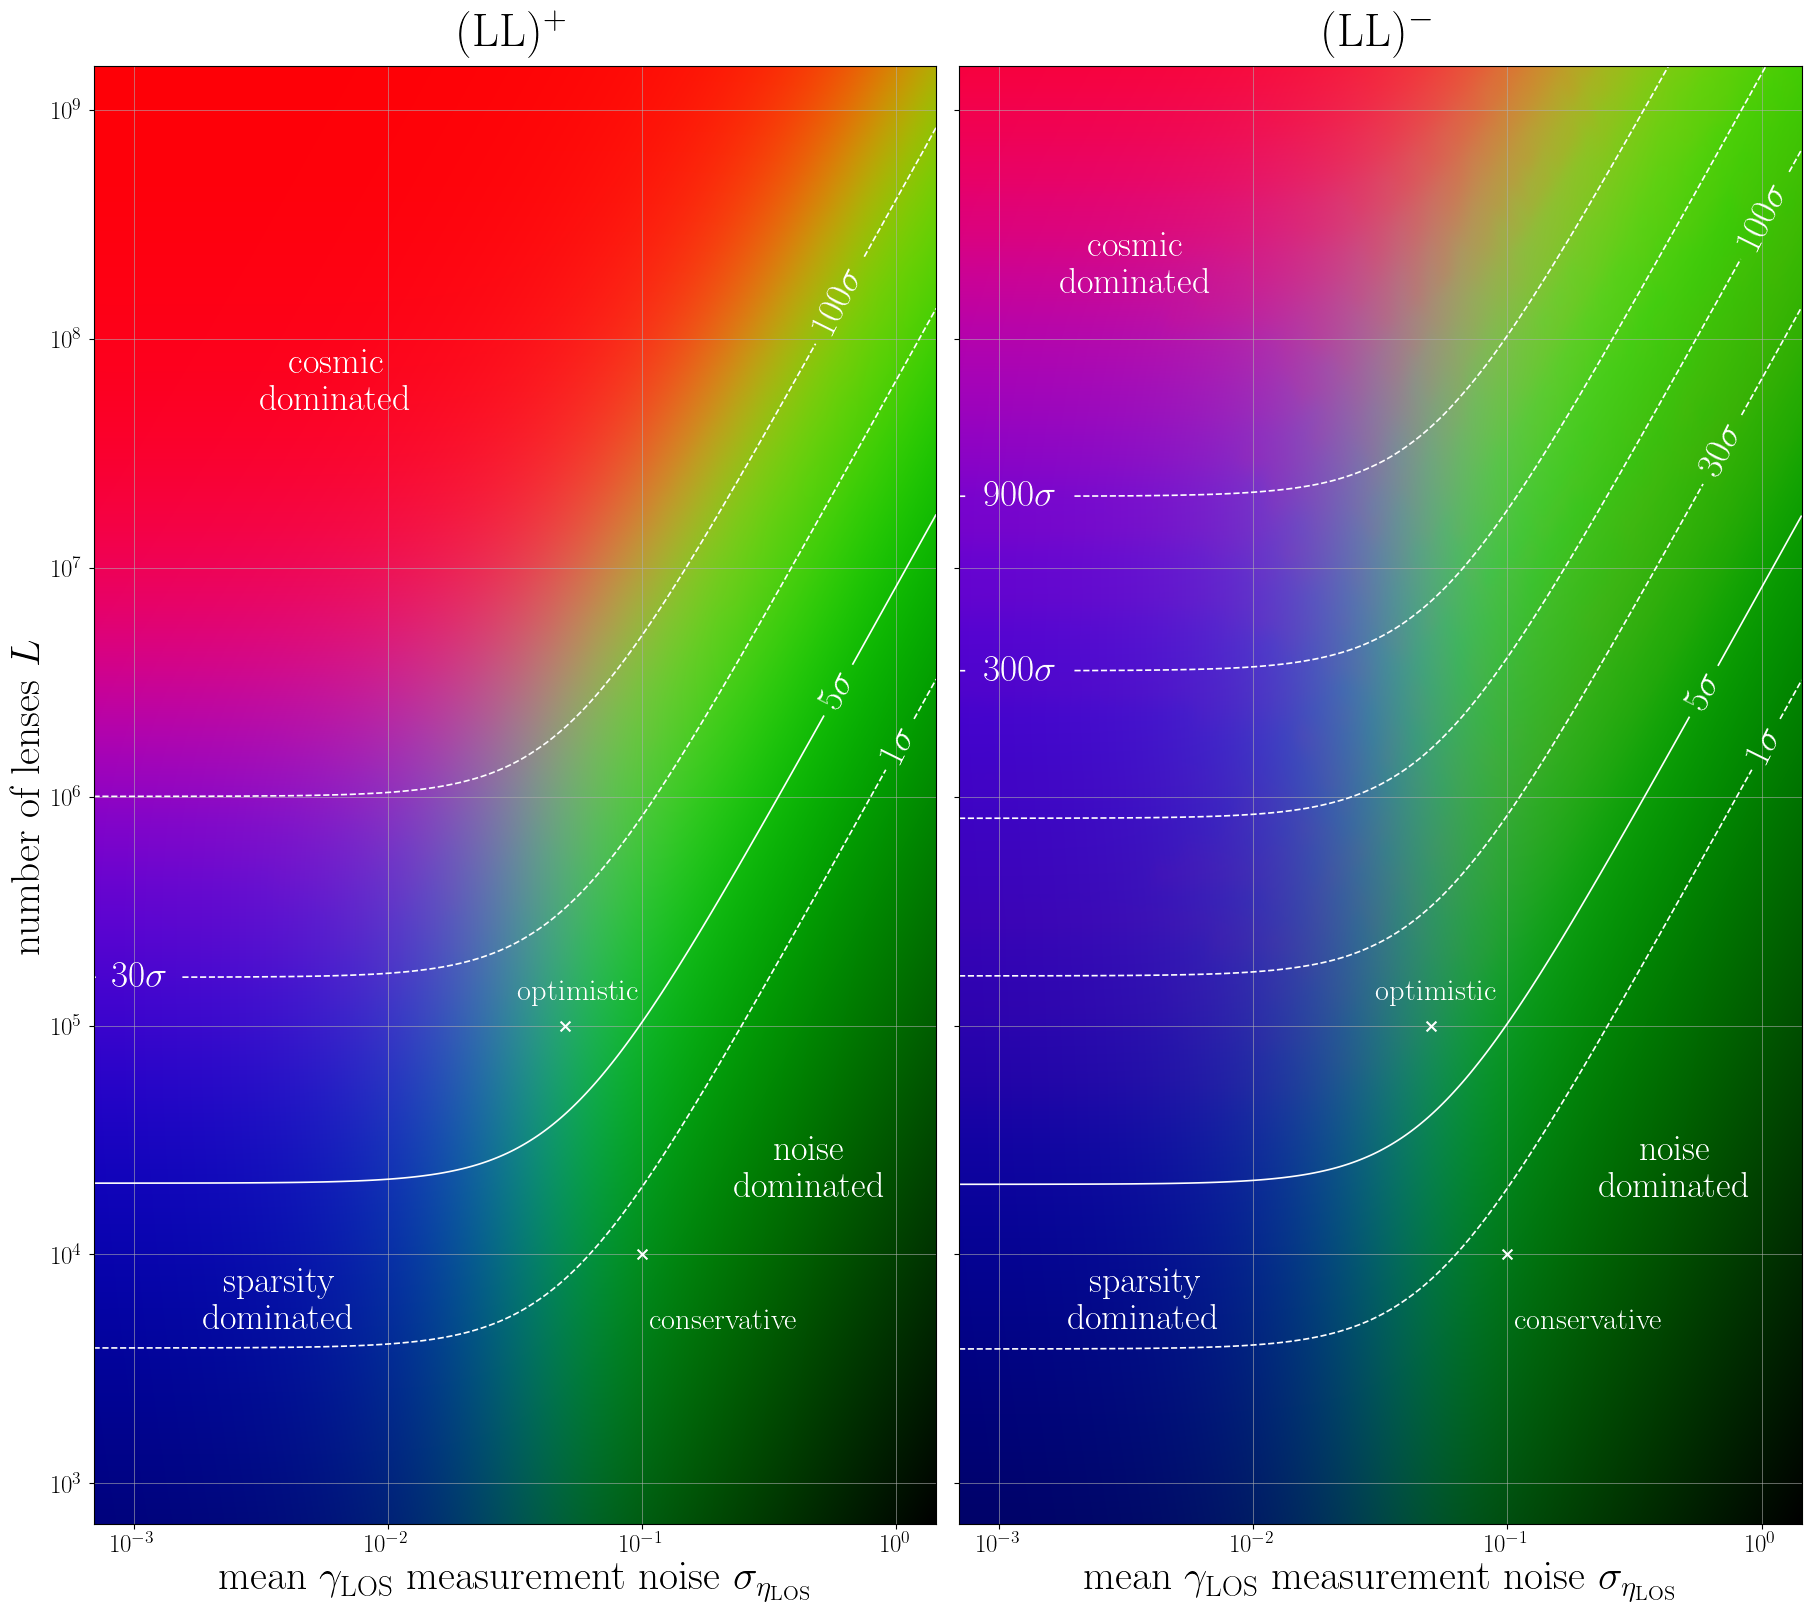

In [204]:
plot_SNR_grid('LL', relative=False, colours = True, log_scale=True, 
                         set_extent = True, smooth=True, 
                         interp_resolution=500, snr_smooth_sigma=0, plot_noise = True,
                         plot_sparsity = True, plot_cosmic= True)

In [205]:
def plot_SNR_grid_all(**kwargs):
    """
    Single figure combining all 5 subplots
    """

    # Create a 3x2 grid
    fig, axes = plt.subplots(3, 2, figsize=(18, 24), sharex=False, sharey=False,
                             constrained_layout=True)

    # Flatten axes for easier indexing
    axes = axes.flatten()

    # Define correlations for each subplot
    correlations = ["LLp", "LLm", "LEp", "LEm", "LP"]
    
    # get vmin/vmax for non-relative/non-colours mode
    vmins, vmaxs = [], []
    for i, corr in enumerate(correlations):
        xlabel = False
        if corr == "LEm" or corr == "LP":
            xlabel = True
        vmin, vmax = plot_SNR_grid_single(corr, ax=axes[i],
                                          add_colourbar=False,
                                          ylabel=(i % 2 == 0),
                                          xlabel=xlabel,
                                          **kwargs)
        vmins.append(vmin)
        vmaxs.append(vmax)

    # Enforce a common scale for all plots
    vmin_all = min(vmins)
    vmax_all = max(vmaxs)
    for ax in axes[:5]:  # ignore the last empty cell if needed
        if ax.images:
            ax.images[0].set_clim(vmin_all, vmax_all)

    # Shared colourbar if appropriate
    if not kwargs.get("relative", True) and not kwargs.get("colours", True):
        # Use last real subplot as mappable
        cbar = fig.colorbar(axes[4].images[0], ax=axes[:5], location='right', shrink=0.9)
        cbar.set_label("log10(SNR)" if kwargs.get("log_scale", True) else "SNR")

    # Hide the last empty subplot
    axes[5].axis('off')

    plt.savefig('Figures/SNR_grid.pdf')
    plt.show()

In [206]:
######## use this to set the range of the axes ##########

xlims = {'LLm': (-3.2,0.2),                 #min -4, max 1
                 'LLp': (-3.2,0.2),
                 'LEm': (-3.2,0.2),
                 'LEp': (-3.2,0.2),
                 'LP': (-3.2,0.2)
}
ylims = {'LLm': (2.8,9.2),                  #min 1, max 10
                 'LLp': (2.8,9.2),
                 'LEm': (1,9.2),
                 'LEp': (1,9.2),
                 'LP': (1,9.2)
}

######## use this to reposition the "noise dominated, sparsity dominated etc labels ##########

#noise, sparsity, cosmic labels
xtext = {'LLp': (0.85, 0.22, 0.288),
         'LLm': (0.85, 0.22, 0.21),
         'LEp': (0.85, 0.22, 0.29),
         'LEm': (0.85, 0.22, None),
         'LP': (0.85, 0.22, 0.27)}

ytext = {'LLp': (0.22, 0.13, 0.76),
         'LLm': (0.22, 0.13, 0.84),
         'LEp': (0.07, 0.19, 0.80),
         'LEm': (0.07, 0.19, None),
         'LP': (0.43, 0.19, 0.85)}

######## use this to reposition the "conservative" and "optimistic" labels ##########

#point label offsets (x,y)
coffset = {'LLp': (0.03, -0.35),
           'LLm': (0.03, -0.35),
           'LEp': (-0.61, -0.37),
           'LEm': (-0.61, -0.37),
           'LP': (-0.25, -0.4)}

ooffset = {'LLp': (-0.19, 0.09),
           'LLm': (-0.22, 0.09),
           'LEp': (-0.25, -0.39),
           'LEm': (-0.25, -0.39),
           'LP': (-0.03, -0.38)}

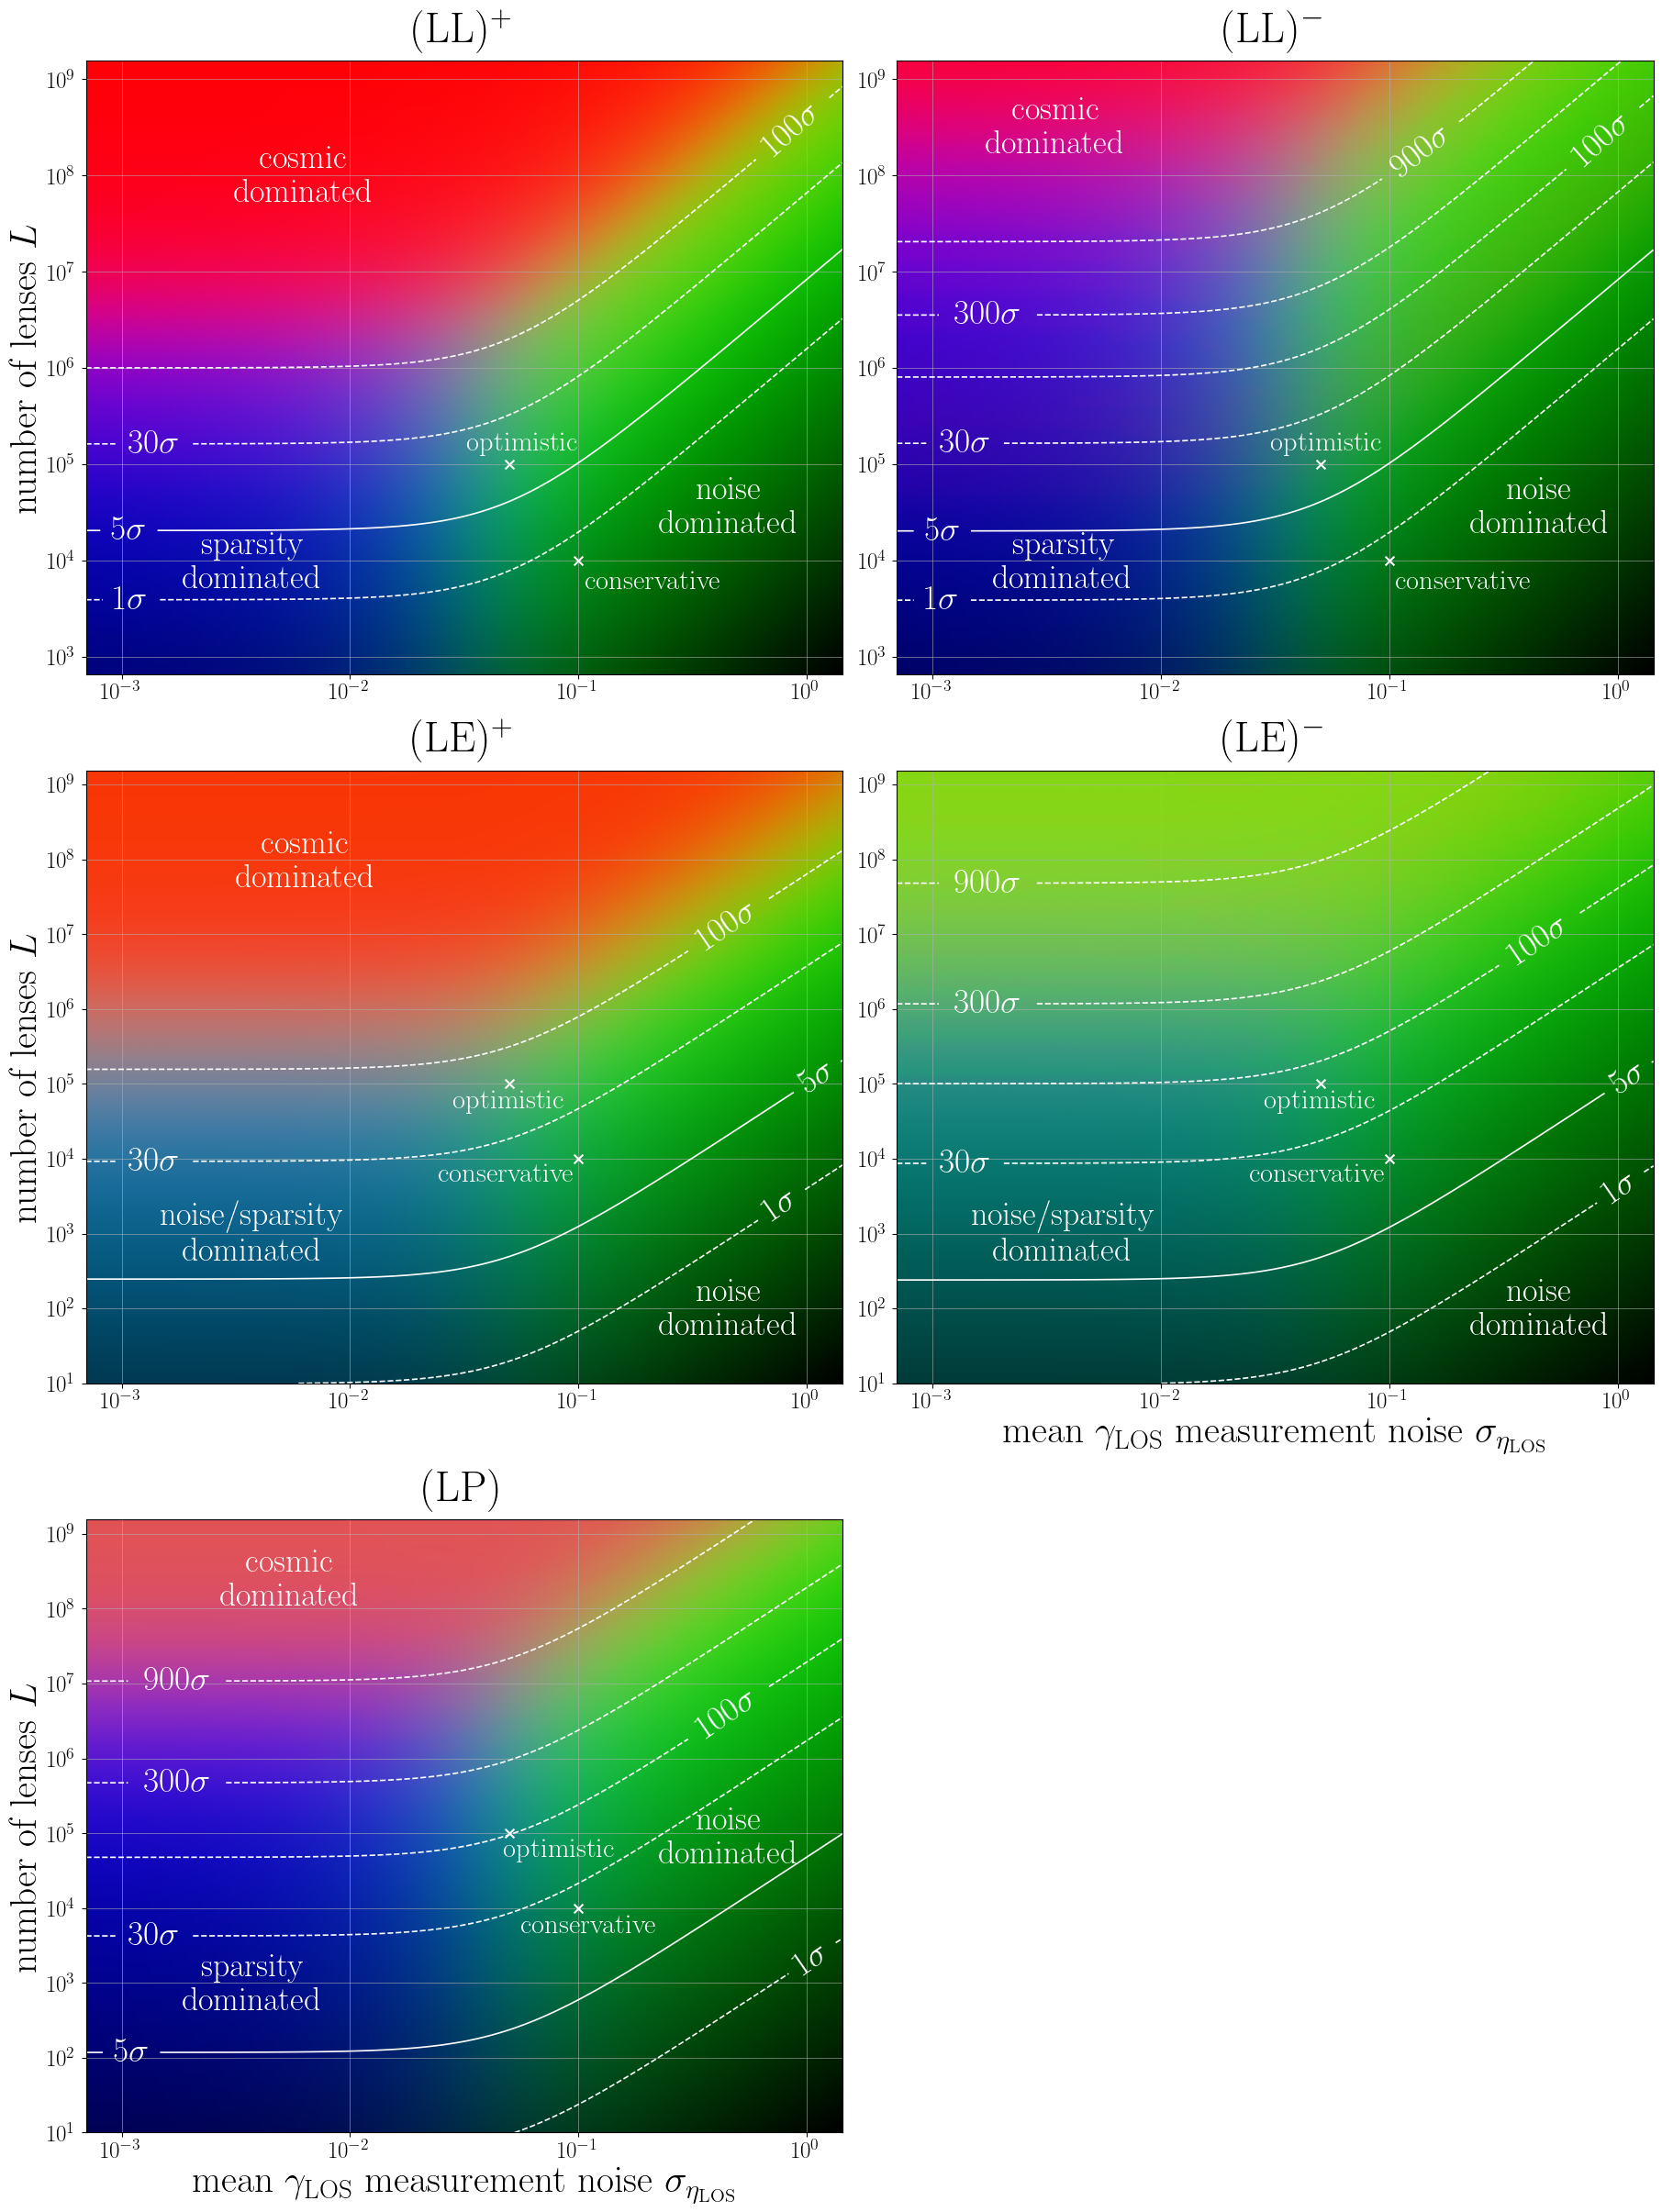

In [207]:
plot_SNR_grid_all(relative=False, colours = True, log_scale=True, 
                         set_extent = True, smooth=True, 
                         interp_resolution=300, snr_smooth_sigma=0, plot_noise = True,
                         plot_sparsity = True, plot_cosmic= True)

## 4. Supplementary plots

### 4.1 A single SNR grid

(-3.6846396725545887, 3.407684121536906)

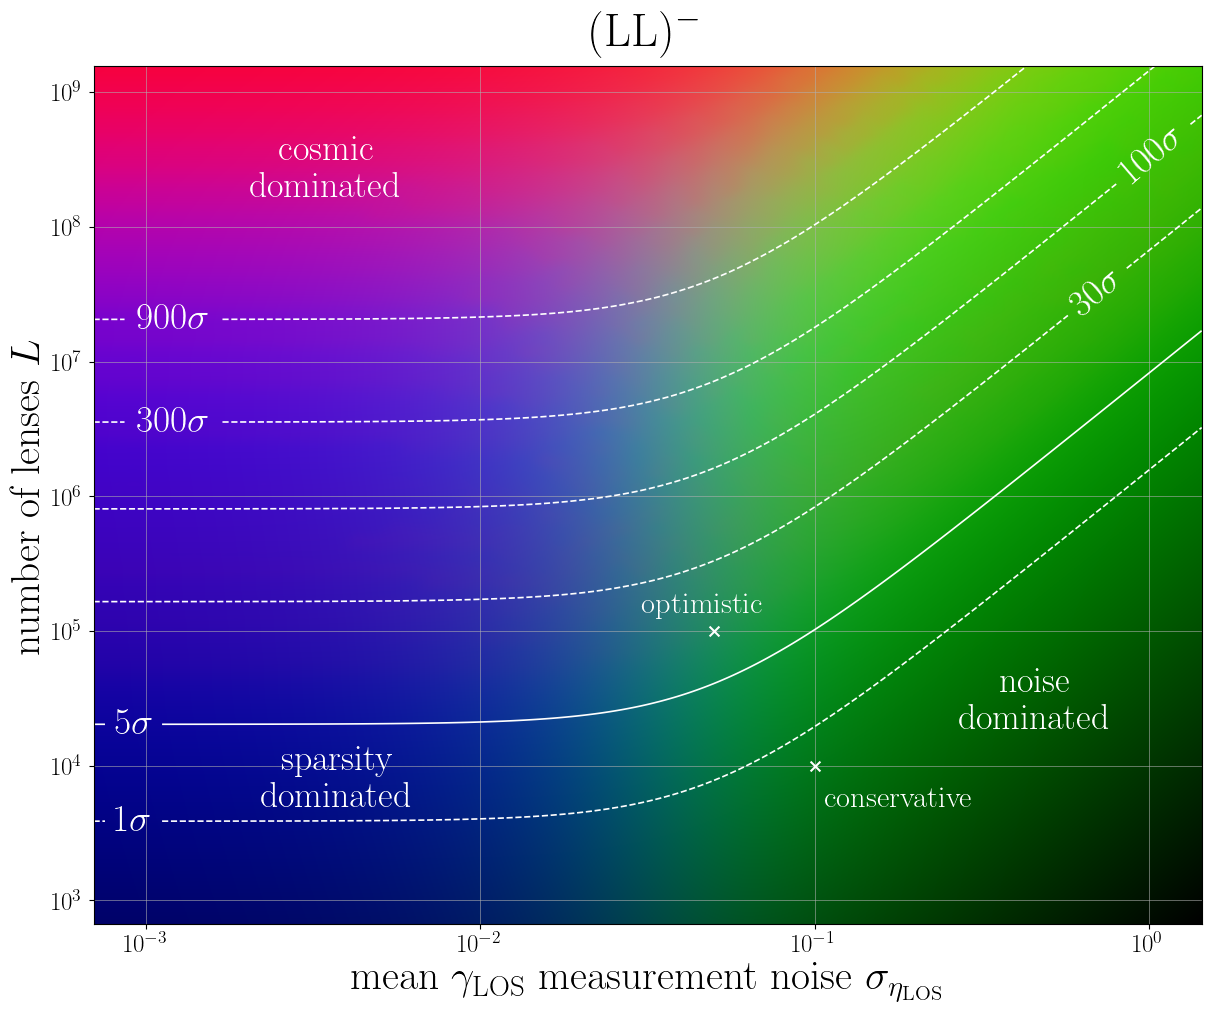

In [208]:
plot_SNR_grid_single('LLm', relative=False, colours = True, log_scale=True, 
                         set_extent = True, figsize=(12, 10), smooth=True, 
                         interp_resolution=500, snr_smooth_sigma=0, plot_noise = True,
                         plot_sparsity = True, plot_cosmic= True)

### 4.2 Plotting thetas

In [209]:
def plot_theta_grid_single(
    correlation,
    figsize=(9, 8),
    log_scale=False,
    smooth=True,
    interp_resolution=200,
    theta_smooth_sigma=1.0, 
    ax=None, ylabel=True, 
    add_colourbar=True,
    textcolor='w'
):
    """
    Intensity map of optimised theta vs sigma_L and Nlens

    Parameters
    ----------
    log_scale : bool
        If True, plot log10(theta)
    smooth : bool
        If True, interpolate to a fine grid
    interp_resolution : int
        Resolution of interpolation grid
    theta_smooth_sigma : float
        Gaussian smoothing sigma (applied after interpolation)
    """

    ###########################################################################
    ############################ Data setup ###################################

    data_dict = dictionary_dict[correlation]

    unique_sigma_L = np.unique(sigma_L_array)
    unique_Nlens = np.unique(Nlens_array)

    param_dict = {(sl, nl): i
                  for i, (sl, nl) in enumerate(zip(sigma_L_array, Nlens_array))}

    theta_grid = np.zeros((len(unique_Nlens), len(unique_sigma_L)))

    for i, nl in enumerate(unique_Nlens):
        for j, sl in enumerate(unique_sigma_L):
            idx = param_dict[(sl, nl)]
            theta_grid[i, j] = data_dict[idx]['optimised_theta']

    if log_scale:
        theta_grid = np.log10(np.maximum(theta_grid, 1e-30))

    ###########################################################################
    ############################ Log axes #####################################

    log_sigma = np.log10(unique_sigma_L)
    log_nlens = np.log10(unique_Nlens)

    log_sigma_min, log_sigma_max = xlims[correlation]
    log_nlens_min, log_nlens_max = ylims[correlation]

    mask_sigma = (log_sigma >= log_sigma_min) & (log_sigma <= log_sigma_max)
    mask_nlens = (log_nlens >= log_nlens_min) & (log_nlens <= log_nlens_max)

    theta_grid = theta_grid[mask_nlens][:, mask_sigma]
    log_sigma = log_sigma[mask_sigma]
    log_nlens = log_nlens[mask_nlens]

    ###########################################################################
    ############################ Interpolation ################################

    if smooth:

        points = []
        values = []

        for i, ln in enumerate(log_nlens):
            for j, ls in enumerate(log_sigma):
                points.append([ls, ln])
                values.append(theta_grid[i, j])

        points = np.array(points)
        values = np.array(values)

        log_sigma_fine = np.linspace(log_sigma.min(), log_sigma.max(), interp_resolution)
        log_nlens_fine = np.linspace(log_nlens.min(), log_nlens.max(), interp_resolution)

        sigma_plot, nlens_plot = np.meshgrid(log_sigma_fine, log_nlens_fine)

        theta_grid = griddata(
            points, values,
            (sigma_plot, nlens_plot),
            method='cubic',
            fill_value=np.nan
        )

        theta_grid = np.nan_to_num(theta_grid, nan=np.nanmin(theta_grid))

        if theta_smooth_sigma > 0:
            theta_grid = gaussian_filter(theta_grid, sigma=theta_smooth_sigma)

        extent = [
            log_sigma_fine.min(), log_sigma_fine.max(),
            log_nlens_fine.min(), log_nlens_fine.max()
        ]

    else:

        sigma_plot, nlens_plot = np.meshgrid(log_sigma, log_nlens)

        extent = [
            log_sigma.min(), log_sigma.max(),
            log_nlens.min(), log_nlens.max()
        ]

    ###########################################################################
    ############################ Plotting #####################################

    # setting up the figure
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        created_fig = False

    im = ax.imshow(
        theta_grid,
        extent=extent,
        origin='lower',
        aspect='auto',
        cmap='inferno'
    )

    if add_colourbar:
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label(
            r'log10($\theta$)' if log_scale else r'$\theta$',
            fontsize=16
        )

    ###########################################################################
    ############################ Labels & ticks ###############################

    ax.set_xlabel(
        r'mean $\gamma_\mathrm{LOS}$ measurement noise $\langle \eta_\mathrm{LOS} \rangle$',
        fontsize=27
    )
    if ylabel:
        ax.set_ylabel(r'number of lenses $L$', fontsize=27)
    ax.set_title(titles[correlation], fontsize=32, pad=15)

    xticks = np.arange(np.ceil(extent[0]), np.floor(extent[1]) + 1)
    yticks = np.arange(np.ceil(extent[2]), np.floor(extent[3]) + 1)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.set_xticklabels([format_sci(10**v) for v in xticks])
    ax.set_yticklabels([format_sci(10**v) for v in yticks])

    ###########################################################################
    ############################ Mark reference points ########################

    # points to mark
    points_sigma = [0.05, 0.1]      # σ_L values
    points_nlens = [100000, 10000]       # N_lens values
    labels = ["optimistic", "conservative"]             # labels

    #adjusting the positioning of the point labels
    offsets = {
        "optimistic": ooffset[correlation],
        "conservative": coffset[correlation]
        }
    
    # Convert to log scale
    log_points_sigma = np.log10(points_sigma)
    log_points_nlens = np.log10(points_nlens)
    
    # Plot points
    ax.scatter(log_points_sigma, log_points_nlens, marker = 'x', color='white', s=50, zorder=5)
    
    # Add labels
    for x, y, lab in zip(log_points_sigma, log_points_nlens, labels):
        dx, dy = offsets[lab]
        ax.text(x + dx, y + dy, lab,
                color=textcolor, fontsize=22,
                ha='left', va='bottom', zorder=6)

    #annotating regions
    ax.text(xtext[correlation][0], ytext[correlation][0], "noise \ndominated",
            transform=ax.transAxes,
             ha='center', va='bottom', color = textcolor,
             fontsize=26)
    if correlation == 'LEp' or correlation == 'LEm':
        ax.text(xtext[correlation][1], ytext[correlation][1], "noise/sparsity \ndominated",
                transform=ax.transAxes,
                 ha='center', va='bottom', color = textcolor,
                 fontsize=26)
    else:
        ax.text(xtext[correlation][1], ytext[correlation][1], "sparsity \ndominated",
                transform=ax.transAxes,
                 ha='center', va='bottom', color = textcolor,
                 fontsize=26)
    if correlation != 'LEm':
        ax.text(xtext[correlation][2], ytext[correlation][2], "cosmic \ndominated",
                transform=ax.transAxes,
                 ha='center', va='bottom', color = textcolor,
                 fontsize=26)
    ax.grid()

    return np.nanmin(theta_grid), np.nanmax(theta_grid)
    
    # plt.tight_layout()
    if created_fig:
        plt.savefig(f'Figures/SNR_grid_{correlation}.png')
        plt.show()

In [210]:
def plot_theta_grid(correlation, **kwargs):

    if correlation in ["LL", "LE"]:

        fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True,
                         constrained_layout=True)

        if correlation == "LL":
            corr1, corr2 = "LLp", "LLm"
        else:
            corr1, corr2 = "LEp", "LEm"

        # First pass: get ranges
        vmin1, vmax1 = plot_theta_grid_single(corr1, ax=axes[0],
                                            add_colourbar=False, ylabel=True, textcolor='w', **kwargs)
        vmin2, vmax2 = plot_theta_grid_single(corr2, ax=axes[1],
                                            add_colourbar=False, ylabel=False, textcolor='k', **kwargs)

        vmin = min(vmin1, vmin2)
        vmax = max(vmax1, vmax2)

        # Now enforce common norm
        for ax in axes:
            im = ax.images[0]
            im.set_clim(vmin, vmax)

        # Shared colourbar
        cbar = fig.colorbar(axes[0].images[0], ax=axes, location='right', shrink=0.9)
        cbar.set_label(r"log10($\theta$)" if kwargs.get("log_scale", True) else r"$\theta$")

        plt.savefig(f'Figures/theta_grid_{correlation}.png')
        
        plt.show()

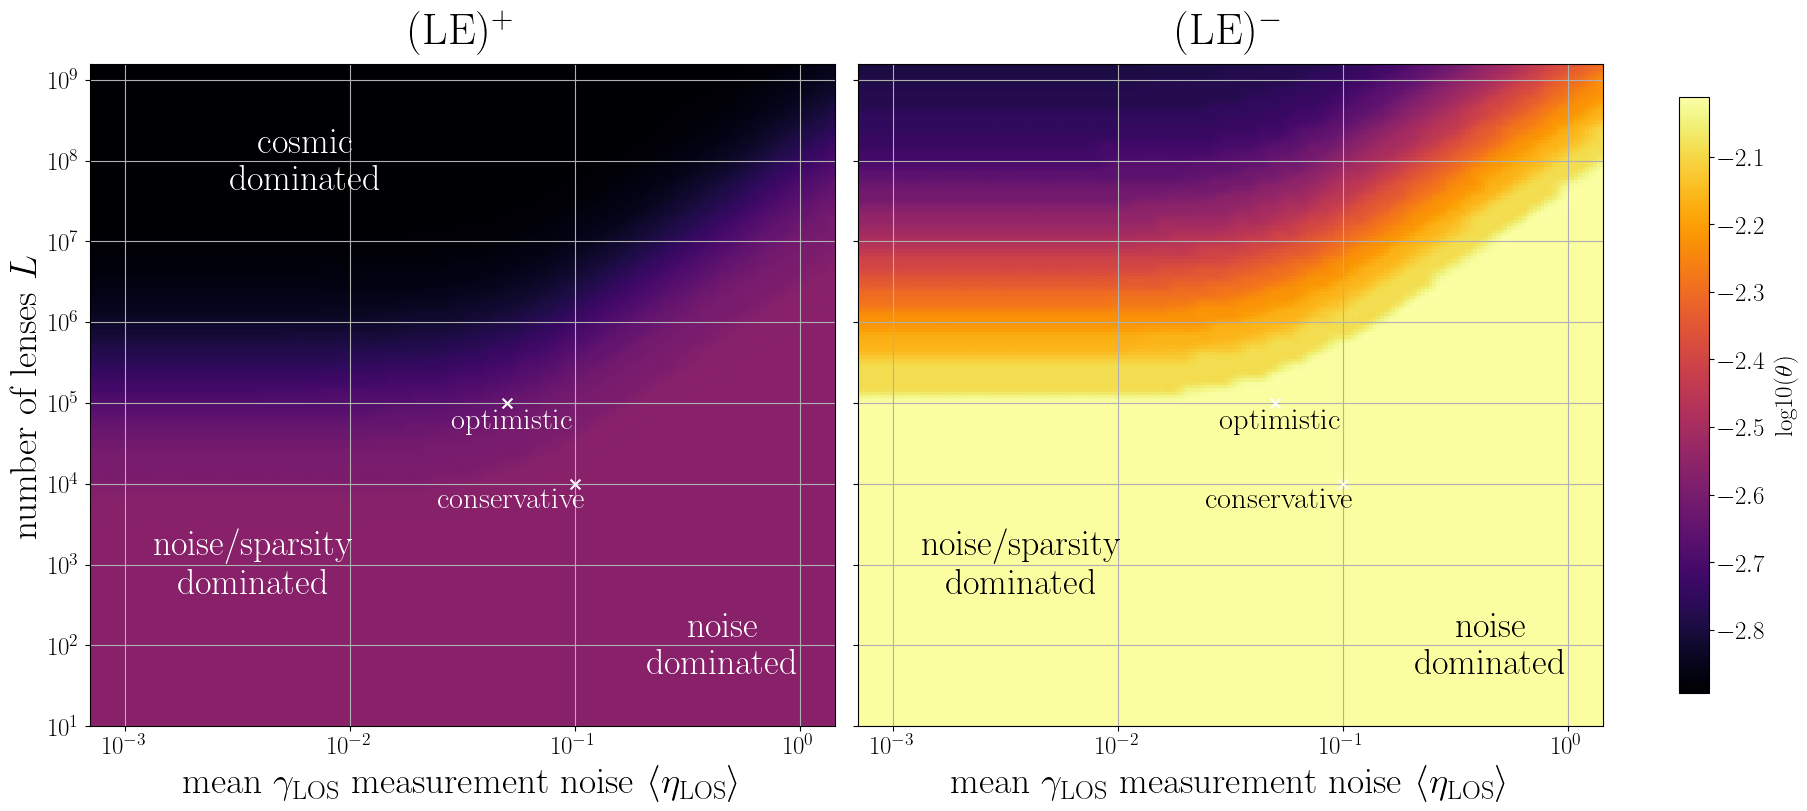

In [211]:
plot_theta_grid(
    'LE',
    log_scale=True,
    smooth=True,
    interp_resolution=200,
    theta_smooth_sigma=1.0
)

(-2.8933245603316284, -2.5657088515479503)

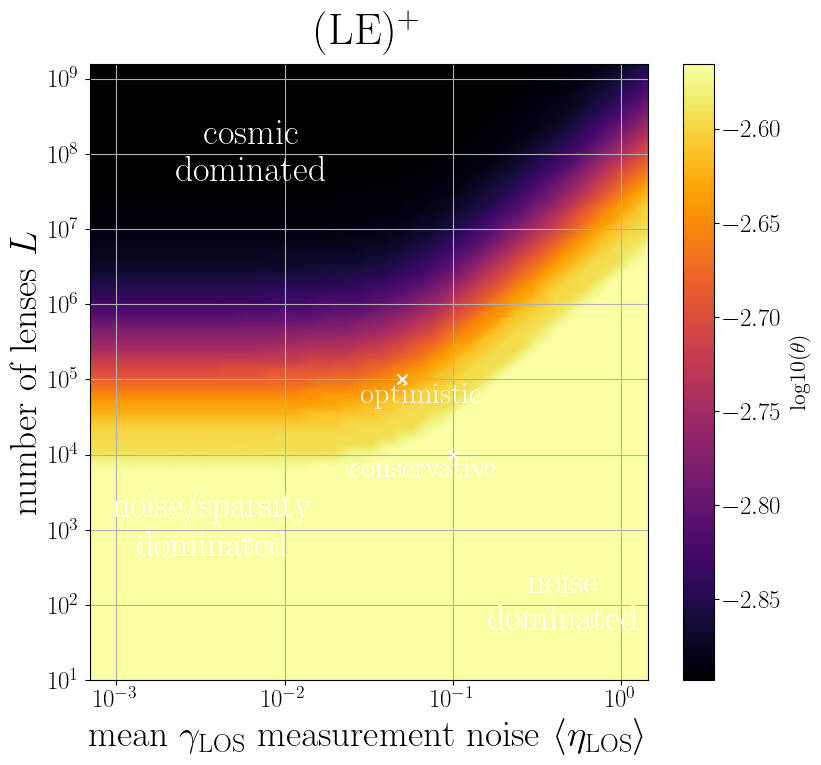

In [212]:
plot_theta_grid_single(
    'LEp',
    log_scale=True,
    smooth=True,
    interp_resolution=200,
    theta_smooth_sigma=1.0
)